In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from tueplots import bundles
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

In [2]:
# configuration
K = 10                          # number of classes
n_total = 5000
n_train = 1000
n_pool = n_total - n_train      # remaining pool for cal/test splits
n_calib = 200
n_test = n_pool - n_calib

num_runs = 20                   # number of random cal/test splits
seed_data = 0                   # seed for the dataset
cluster_std = 2.5

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [3]:
# generate dataset and fit base classifier

np.random.seed(seed_data)
X_all, y_all = make_blobs(
    n_samples=n_total, centers=K, n_features=2,
    cluster_std=cluster_std, random_state=seed_data
)

X_train, y_train = X_all[:n_train], y_all[:n_train]
X_pool, y_pool = X_all[n_train:], y_all[n_train:]

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("train accuracy:", (model.predict(X_train) == y_train).mean())


def scores_all(Xa):
    """(m, K) matrix of S(x, y) = 1 - p_hat(y|x) for every candidate label y."""
    return 1.0 - model.predict_proba(Xa)

train accuracy: 0.647


## Conformal p-values and e-values

For each candidate label $y$ and test point $x$:

**P-value:** $\pi_x(y) = \frac{1 + \#\{i : S(X_i, Y_i) \geq S(x, y)\}}{n_{\text{cal}} + 1}$

**Soft-rank e-value:** $E(x,y) = \frac{(n+1) \, S(x,y)}{\Sigma + S(x,y)}$, where $\Sigma = \sum_i S(X_i, Y_i)$

**Transformed e-value (to p-value scale):** $\tilde{\pi}(y) = \min(1, 1/E(x,y))$

In [4]:
# conformal p-values for classification

def conformal_pvalues(S_calib_true, S_test_all):
    """
    Compute conformal p-values for each test point and each candidate label.

    Parameters
    ----------
    S_calib_true : (n_calib,) calibration scores for true labels
    S_test_all   : (n_test, K) scores for each test point and candidate label

    Returns
    -------
    pvals : (n_test, K)
    """
    n = len(S_calib_true)
    # for each test point and candidate label, count calibration scores >= candidate score
    # S_calib_true: (n,)  S_test_all: (m, K)
    counts = (S_calib_true[None, :, None] >= S_test_all[:, None, :]).sum(axis=1)  # (m, K)
    return (1 + counts) / (n + 1)


def soft_rank_evalues(S_calib_true, S_test_all):
    """
    Compute soft-rank e-values for each test point and each candidate label.

    E(x,y) = (n+1) * S(x,y) / (Sigma + S(x,y))

    Parameters
    ----------
    S_calib_true : (n_calib,) calibration scores for true labels
    S_test_all   : (n_test, K) scores for each test point and candidate label

    Returns
    -------
    evals : (n_test, K)
    """
    n = len(S_calib_true)
    Sigma = S_calib_true.sum()
    return (n + 1) * S_test_all / (Sigma + S_test_all)


def evals_to_pvals(evals):
    """Transform e-values to p-value scale via min(1, 1/e)."""
    return np.minimum(1.0, 1.0 / np.clip(evals, 1e-15, None))

## MMI measures

**MMI-TV:** $\text{MMI}_{\mathcal{H}_{TV}} = \pi_{\sigma(2)}$ (second largest p-value)

**MMI-$\pi_x$:** $\text{MMI}_{\{\pi_x\}} = \sum_{k=2}^{K+1} (\pi_{\sigma(k-1)} - \pi_{\sigma(k)}) \cdot \pi_{\sigma(k)}$

where $\pi_{\sigma(1)} \geq \pi_{\sigma(2)} \geq \cdots \geq \pi_{\sigma(K)}$ and $\pi_{\sigma(K+1)} := 0$.

In [5]:
def mmi_tv(pvals):
    """
    MMI-TV for each test point: second largest p-value.

    Parameters
    ----------
    pvals : (n_test, K) — p-values (or transformed e-values) per candidate label

    Returns
    -------
    (n_test,)
    """
    sorted_desc = np.sort(pvals, axis=1)[:, ::-1]  # descending
    return sorted_desc[:, 1]  # second largest


def mmi_pi(pvals):
    """
    MMI-pi_x for each test point.

    MMI = sum_{k=2}^{K+1} (pi_sigma(k-1) - pi_sigma(k)) * pi_sigma(k)
    with pi_sigma(K+1) = 0.

    Parameters
    ----------
    pvals : (n_test, K)

    Returns
    -------
    (n_test,)
    """
    sorted_desc = np.sort(pvals, axis=1)[:, ::-1]  # (n_test, K), descending
    # append pi_{K+1} = 0
    padded = np.concatenate([sorted_desc, np.zeros((len(sorted_desc), 1))], axis=1)
    # sum from k=2 to K+1:  (pi(k-1) - pi(k)) * pi(k)
    # k runs 2..K+1, so index k-1 runs 1..K in padded
    gaps = padded[:, :-1] - padded[:, 1:]   # (n_test, K)
    vals = padded[:, 1:]                     # (n_test, K)
    # we want k=2..K+1, which is index 1..K in gaps/vals
    return (gaps[:, 1:] * vals[:, 1:]).sum(axis=1)

In [6]:
# run conformal prediction with random cal/test splits

results = {
    'mmi_tv_pval':  [],
    'mmi_tv_eval':  [],
    'mmi_pi_pval':  [],
    'mmi_pi_eval':  [],
}

for run in range(num_runs):
    rng = np.random.RandomState(run)
    perm = rng.permutation(n_pool)
    idx_cal = perm[:n_calib]
    idx_test = perm[n_calib:]

    X_calib, y_calib = X_pool[idx_cal], y_pool[idx_cal]
    X_test, y_test = X_pool[idx_test], y_pool[idx_test]

    # calibration scores (true labels only)
    S_calib_all = scores_all(X_calib)
    S_calib_true = S_calib_all[np.arange(n_calib), y_calib]

    # test scores (all candidate labels)
    S_test_all = scores_all(X_test)

    # p-values
    pvals = conformal_pvalues(S_calib_true, S_test_all)

    # soft-rank e-values -> transformed p-values
    evals = soft_rank_evalues(S_calib_true, S_test_all)
    pvals_from_e = evals_to_pvals(evals)

    # compute all four MMI measures
    results['mmi_tv_pval'].append(mmi_tv(pvals))
    results['mmi_tv_eval'].append(mmi_tv(pvals_from_e))
    results['mmi_pi_pval'].append(mmi_pi(pvals))
    results['mmi_pi_eval'].append(mmi_pi(pvals_from_e))

    if run % 5 == 0:
        print(f"run {run+1}/{num_runs}")

print("done")

# stack: each entry becomes (num_runs, n_test)
for key in results:
    results[key] = np.array(results[key])

run 1/20
run 6/20
run 11/20
run 16/20
done


In [7]:
# summary: mean and std of each MMI measure across runs

print(f"{'measure':<20} {'mean':>10} {'std':>10}")
print("-" * 42)
for key in results:
    # mean over test points, then over runs
    per_run_means = results[key].mean(axis=1)  # (num_runs,)
    print(f"{key:<20} {per_run_means.mean():10.4f} {per_run_means.std():10.4f}")

measure                    mean        std
------------------------------------------
mmi_tv_pval              0.1953     0.0204
mmi_tv_eval              0.6044     0.0301
mmi_pi_pval              0.0118     0.0028
mmi_pi_eval              0.0668     0.0064


In [8]:
from scipy.stats import spearmanr

# use first run as representative
run_idx = 0
keys = list(results.keys())
labels = ['MMI-TV (p)', 'MMI-TV (e)', r'MMI-$\pi_x$ (p)', r'MMI-$\pi_x$ (e)']

n_measures = len(keys)
corr_matrix = np.ones((n_measures, n_measures))

for i in range(n_measures):
    for j in range(i + 1, n_measures):
        rho, _ = spearmanr(results[keys[i]][run_idx], results[keys[j]][run_idx])
        corr_matrix[i, j] = rho
        corr_matrix[j, i] = rho

print("Spearman rank correlations (run 0):")
print(f"{'':>18}", end="")
for l in labels:
    print(f"{l:>18}", end="")
print()
for i, l in enumerate(labels):
    print(f"{l:>18}", end="")
    for j in range(n_measures):
        print(f"{corr_matrix[i, j]:18.3f}", end="")
    print()

Spearman rank correlations (run 0):
                          MMI-TV (p)        MMI-TV (e)   MMI-$\pi_x$ (p)   MMI-$\pi_x$ (e)
        MMI-TV (p)             1.000             0.999             0.888             0.998
        MMI-TV (e)             0.999             1.000             0.887             0.999
   MMI-$\pi_x$ (p)             0.888             0.887             1.000             0.902
   MMI-$\pi_x$ (e)             0.998             0.999             0.902             1.000


C:\Users\User\AppData\Local\Temp\ipykernel_44052\2543996381.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


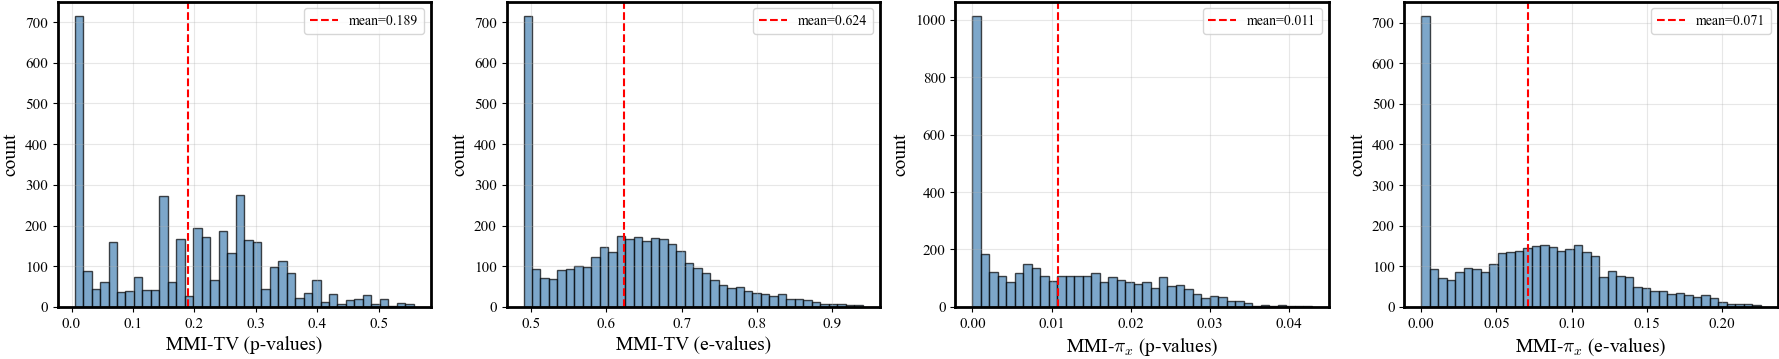

In [9]:
# plot distributions of all four MMI measures (first run)

plt.rcParams.update(bundles.icml2024(usetex=False))
plt.rcParams.update({
    "axes.labelsize": 14, "axes.titlesize": 14,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.fontsize": 10, "lines.linewidth": 2, "axes.linewidth": 2,
})

fig, axs = plt.subplots(1, 4, figsize=(18, 3.8))

titles = ['MMI-TV (p-values)', 'MMI-TV (e-values)',
          r'MMI-$\pi_x$ (p-values)', r'MMI-$\pi_x$ (e-values)']

for ax, key, title in zip(axs, results.keys(), titles):
    vals = results[key][0]  # first run
    ax.hist(vals, bins=40, edgecolor='k', alpha=0.7, color='steelblue')
    ax.axvline(vals.mean(), color='red', ls='--', lw=1.5, label=f'mean={vals.mean():.3f}')
    ax.set_xlabel(title)
    ax.set_ylabel("count")
    ax.legend(frameon=True)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/mmi_distributions.pdf", format="pdf", bbox_inches="tight")
plt.savefig("plots/mmi_distributions.png", format="png", dpi=160, bbox_inches="tight")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_44052\1180937542.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


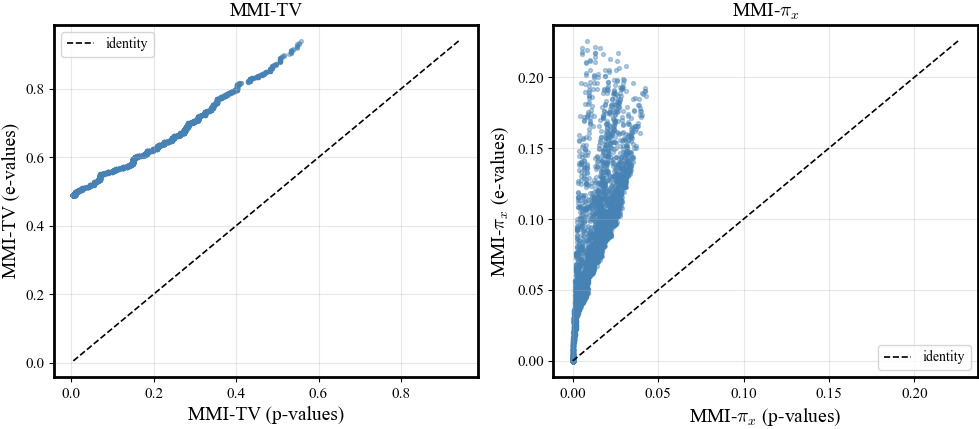

In [10]:
# scatter: p-value-based vs e-value-based MMI

fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, pkey, ekey, title in zip(
    axs,
    ['mmi_tv_pval', 'mmi_pi_pval'],
    ['mmi_tv_eval', 'mmi_pi_eval'],
    ['MMI-TV', r'MMI-$\pi_x$'],
):
    x = results[pkey][0]
    y = results[ekey][0]
    ax.scatter(x, y, s=8, alpha=0.4, color='steelblue')
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='identity')
    ax.set_xlabel(f'{title} (p-values)')
    ax.set_ylabel(f'{title} (e-values)')
    ax.set_title(title)
    ax.legend(frameon=True)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/mmi_pval_vs_eval.pdf", format="pdf", bbox_inches="tight")
plt.savefig("plots/mmi_pval_vs_eval.png", format="png", dpi=160, bbox_inches="tight")
plt.show()